# P4: Imlo tuzatish va LSH qidiruv tizimi

**Mavzu:** Levenshtein tahrir masofasi, Noisy Channel imlo tuzatish, MinHash LSH qidiruv  
**Kun:** 5-kun amaliyoti — 22-iyun 2026, 09:30–10:50 (80 daqiqa)  
**Juftlashgan ma'ruza:** L4 — Masofaga asoslangan qidiruv va imlo tuzatish ([PDF](../lectures/d04_qidiruv_imlo.pdf))  
**Ma'lumot:** mini Uzbek news corpus (`uz_news_corpus.txt`, 160 hujjat). Kaggle uchun faqat shu text fayl kerak  
**GPU:** kerak emas; Kaggle CPU yetarli.

Bugungi amaliyotda kechagi `PretrainedEmbedder` capstone moduliga imlo tuzatish va
hujjat qidirish modulini ulaymiz: xato soʼz → Noisy Channel tuzatish → MinHash LSH
indeksiga kiritish → top-k oʼxshash hujjatlar.

**Bugungi maqsadlar:**
1. Levenshtein tahrir masofasini DP jadval bilan implementatsiya qilish.
2. Noisy Channel ($\arg\max P(w)\,P(x{\mid}w)$) bilan imlo tuzatish.
3. MinHash LSH indeksini qurish (datasketch yoki toza-python).
4. LSH va k-NN (brute-force) qidiruv tezligini taqqoslash.
5. `SpellLSHRetriever` klassini — Option C koʼrinishida capstone moduliga ulash.

| Boʼlim | Tavsif | Vaqt |
|---:|---|---:|
| 1 | Muhit va korpus | 5 daq |
| 2 | Yaxlit natija — pirovard manzil | 8 daq |
| 3 | Jaccard → MinHash → LSH math bridge + PRIMM | 22 daq |
| 4 | Asosiy mavzu — soʼnuvchi tayanch | 30 daq |
| 5 | Loyihaga ulash (`SpellLSHRetriever`) | 10 daq |
| 6 | Tadqiqot + yakun | 5 daq |

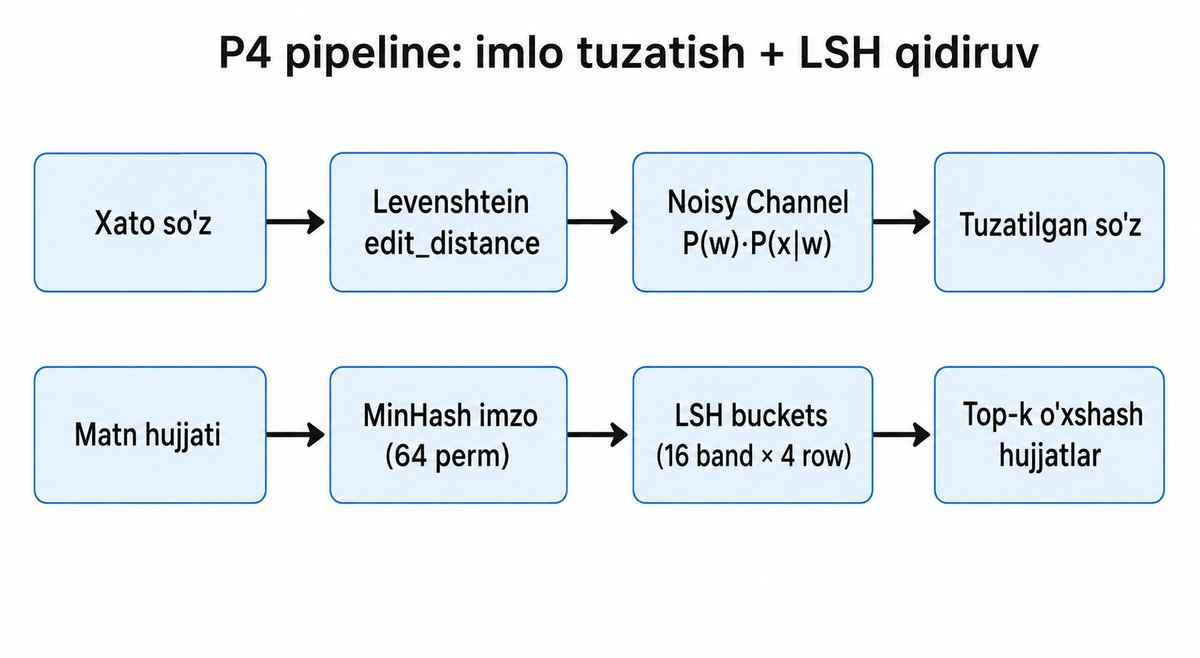

In [54]:
# Paketlar haqida qisqa izoh
# Kaggle CPU runtime odatda kerakli paketlarni allaqachon beradi.
# Ishlatamiz: numpy, matplotlib, datasketch (opsional).
# datasketch boʼlmasa toza-python MinHash ishlatiladi — hech narsani oʼrnatish shart emas.
# GPU, PyTorch, transformers bu darsda kerak emas.

In [55]:
# ============================================================
# 1. Muhit tekshiruvi
# ============================================================
import re, random, os, sys, time, json, zlib
from pathlib import Path
from collections import Counter
import numpy as np

random.seed(42)
np.random.seed(42)

OFFLINE_FALLBACK     = True   # True -> lokal fayl; False -> Kaggle online
SAVE_CAPSTONE_MODULE = False  # True -> m04_spell_lsh_retriever.py faylga saqlash (ixtiyoriy)

# ─── Modul va maʼlumot yoʼllari ────────────────────────────────────────────
def find_module_dir():
    """m01_text_preprocessor ni lokal yoki Kaggle muhitida qidiradi."""
    candidates = [
        Path("../../capstone/modules"),
        Path("../capstone/modules"),
        Path("capstone/modules"),
        Path("/kaggle/working/capstone/modules"),
    ]
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        candidates.extend(p.parent for p in kaggle_root.rglob("m01_text_preprocessor.py"))
    return next((p for p in candidates if (p / "m01_text_preprocessor.py").exists()), None)

def find_data_file(filename="uz_news_corpus.txt"):
    """Korpus faylini lokal yoki Kaggle muhitida qidiradi."""
    candidates = [
        Path("d05_checkpoints") / filename,
        Path("practices/d05_checkpoints") / filename,
    ]
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        candidates.extend(kaggle_root.rglob(filename))
    return next((p for p in candidates if p.exists()), None)

CHECKPOINT_DIR = Path("d05_checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

# ─── m01 TextPreprocessor ────────────────────────────────────────────
module_dir = find_module_dir()
if module_dir is not None:
    sys.path.insert(0, str(module_dir.resolve()))
    from m01_text_preprocessor import TextPreprocessor
    MODULES_DIR   = module_dir
    MODULE_SOURCE = f"m01 TextPreprocessor: {module_dir}"
else:
    _APO  = re.compile("[\u2018\u2019\u02bc\u02bb'’]")
    _TOK  = re.compile("[a-z][a-z']*")
    _STOP = {"va","bu","bir","ham","lekin","uchun","bilan","ga","da",
             "ni","dan","ning","men","sen","biz","siz","ular"}
    class TextPreprocessor:
        def preprocess(self, text):
            text = _APO.sub("'", text.lower())
            return [w for w in _TOK.findall(text) if w not in _STOP and len(w) > 1]
        def preprocess_batch(self, texts):
            return [self.preprocess(t) for t in texts]
    MODULES_DIR   = Path("nlp-capstones-code")
    MODULE_SOURCE = "fallback mini TextPreprocessor (m01 fayli topilmadi)"

pre = TextPreprocessor()

# ─── Datasketch mavjudligini tekshirish ────────────────────────────────────────
try:
    import datasketch
    HAS_DATASKETCH = True
except ImportError:
    HAS_DATASKETCH = False

# ─── Korpus yuklash ────────────────────────────────────────────────────
DATA_FILE = find_data_file("uz_news_corpus.txt")
if DATA_FILE is not None:
    CORPUS = [l.strip() for l in DATA_FILE.open(encoding="utf-8") if l.strip()]
    CORPUS_SOURCE = f"fayl: {DATA_FILE}"
elif OFFLINE_FALLBACK:
    CORPUS = [
        "yangi telefon bozorda chiqdi", "yangi telefon mamlakatda ishga tushdi",
        "internet tezligi yaxshilandi",  "kompyuter texnologiyalari rivojlandi",
        "yangi dastur sinovdan o'tdi",   "internet xavfsizligi muhim masala",
    ] * 10
    CORPUS_SOURCE = "ichki fallback namuna (60 hujjat)"
else:
    raise FileNotFoundError("uz_news_corpus.txt topilmadi.")

print(f"Python      : {sys.version.split()[0]}")
print(f"numpy       : {np.__version__}")
_ds = 'bor' if HAS_DATASKETCH else "yo'q (toza-python LSH ishlatiladi)"
print(f"datasketch  : {_ds}")
print(f"Modul manbai: {MODULE_SOURCE}")
print(f"Korpus      : {len(CORPUS)} hujjat  ({CORPUS_SOURCE})")
print("\n✓ Muhit tayyor.")

Python      : 3.12.13
numpy       : 2.0.2
datasketch  : yo'q (toza-python LSH ishlatiladi)
Modul manbai: m01 TextPreprocessor: /kaggle/input/datasets/khilolakhushmanova/nlp-capstones-code
Korpus      : 160 hujjat  (fayl: /kaggle/input/datasets/khilolakhushmanova/uz-news-corpus/uz_news_corpus.txt)

✓ Muhit tayyor.


## 2. Yaxlit natija — pirovard manzil birinchi!

Quyida **tugallangan tizim** demosi: xato soʼzʼni **tuzatamiz** va soʼrovga
**oʼxshash hujjatlarni** topamiz. Hozir tushuntirishdan oldin — natijani koʼring.

In [56]:
# Pirovard natija (5-bo'limda quriladigan SpellLSHRetriever ning soddalashtirilgan versiyasi)

def _ed(s1, s2):
    m, n = len(s1), len(s2)
    D = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1): D[i][0] = i
    for j in range(n+1): D[0][j] = j
    for i in range(1, m+1):
        for j in range(1, n+1):
            D[i][j] = (D[i-1][j-1] if s1[i-1]==s2[j-1]
                       else 1+min(D[i-1][j], D[i][j-1], D[i-1][j-1]))
    return D[m][n]

_freq  = Counter(w for d in CORPUS for w in pre.preprocess(d))
_total = sum(_freq.values())

def _correct(x):
    x = x.lower()
    if x in _freq: return x
    scored = [(_freq[w] / _total * (0.1**_ed(x, w)), w)
              for w in _freq if _ed(x, w) <= 2]
    return max(scored)[1] if scored else x

print(f"Korpus   : {len(CORPUS)} hujjat")
print(f"correct('telfon')  -> {_correct('telfon')}")
print(f"correct('internt') -> {_correct('internt')}")

q   = CORPUS[0]
sim = sorted(CORPUS, key=lambda d: -len(set(pre.preprocess(d)) & set(pre.preprocess(q))))[:3]
print(f"\nSo'rov   : '{q}'")
print("Eng o'xshash 3 hujjat:")
for d in sim: print(f"  - {d}")
print("\n✓ Tizim ishladi! Quyida har qadamni o'rganamiz.")

Korpus   : 160 hujjat
correct('telfon')  -> telefon
correct('internt') -> internet

So'rov   : 'yangi telefon bozorda chiqdi'
Eng o'xshash 3 hujjat:
  - yangi telefon bozorda chiqdi
  - yangi telefon shaharda chiqdi
  - yangi dastur bozorda chiqdi

✓ Tizim ishladi! Quyida har qadamni o'rganamiz.


## 3. Tayyor kod bloki

### 3A. MinHash LSH gʼoyasi

> **Bashorat qiling** — kodni ishlatishdan oldin javob bering:  
> Millionlab hujjat orasidan oʼxshashini topish uchun har biriga solishtirish ($O(N)$) juda sekin.  
> LSH oʼxshash hujjatlarni bir “savatga” tushiradi. Sizningcha, hash funksiyalari
> qanday tanlansa, oʼxshash hujjatlar bir savatga tushadi?

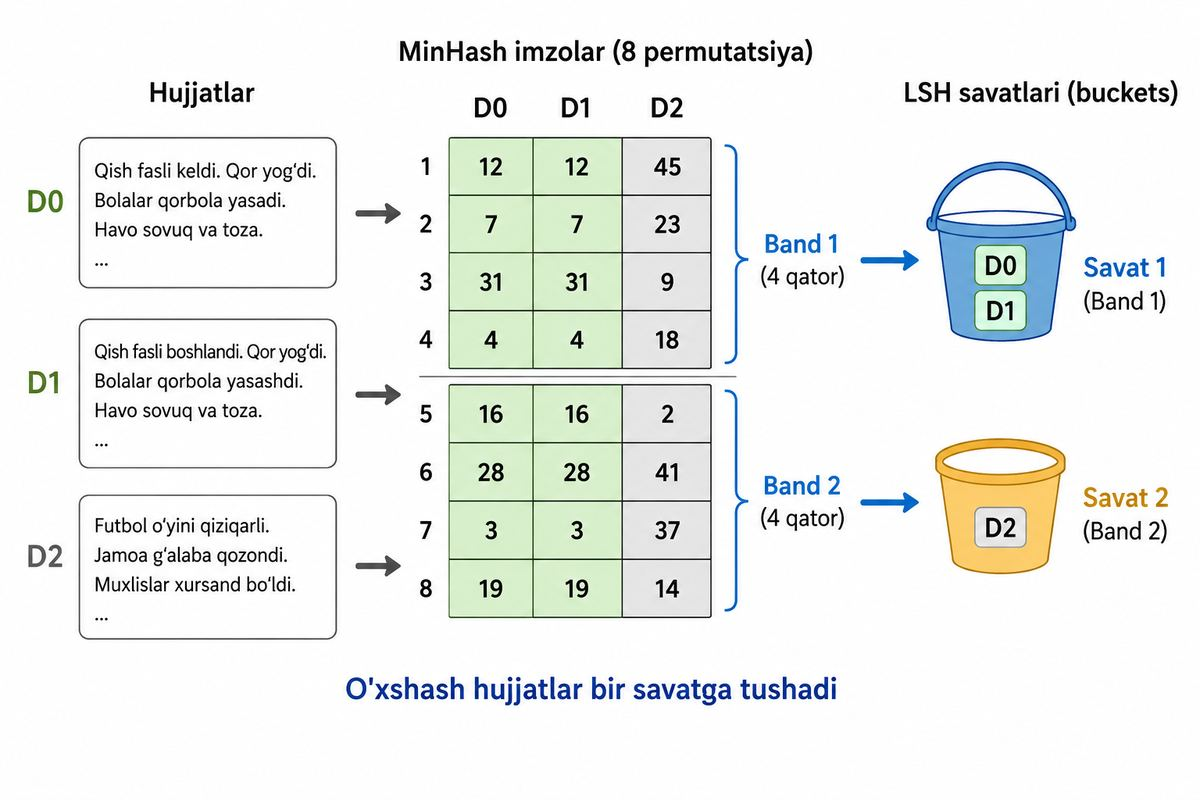

### 3A-1. Jaccard: avval o'xshashlikni to'plam sifatida ko'ramiz

LSH dan oldin savol oddiy: ikki hujjat **qanchalik bir xil tokenlarga ega**?

Agar hujjat tokenlarini to'plamga aylantirsak:

$$
J(A,B)=\frac{|A\cap B|}{|A\cup B|}
$$

- $A\cap B$ — ikkala hujjatda ham bor tokenlar.
- $A\cup B$ — kamida bittasida bor tokenlar.
- Takrorlar sanalmaydi: `telefon telefon` ham set ichida bitta `telefon` bo'ladi.

Jaccard `0` bo'lsa umumiy token yo'q; `1` bo'lsa to'plamlar bir xil.


In [57]:
# Juda kichik qo'lda hisoblanadigan Jaccard misoli
A = {"yangi", "telefon", "bozor", "chiqdi"}
B = {"yangi", "telefon", "shahar", "chiqdi"}
C = {"arzon", "tarmoq", "maktab", "ish"}

def jaccard_set(x, y):
    return len(x & y) / len(x | y) if (x | y) else 0.0

print("A ∩ B =", sorted(A & B))
print("A ∪ B =", sorted(A | B))
print(f"J(A,B) = {len(A & B)}/{len(A | B)} = {jaccard_set(A,B):.2f}")
print(f"J(A,C) = {len(A & C)}/{len(A | C)} = {jaccard_set(A,C):.2f}")
print("\nXulosa: B A ga yaqinroq, chunki umumiy tokenlar ko'proq.")


A ∩ B = ['chiqdi', 'telefon', 'yangi']
A ∪ B = ['bozor', 'chiqdi', 'shahar', 'telefon', 'yangi']
J(A,B) = 3/5 = 0.60
J(A,C) = 0/8 = 0.00

Xulosa: B A ga yaqinroq, chunki umumiy tokenlar ko'proq.


### 3A-2. MinHash: Jaccard ni tez taxmin qilish g'oyasi

MinHash g'oyasini bitta tasodifiy tartib bilan tasavvur qiling:

1. Barcha tokenlarni tasodifiy tartibga joylaymiz.
2. Har bir hujjat uchun shu tartibda **birinchi uchragan token**ni olamiz.
3. Ikki hujjatda birinchi token bir xil chiqsa, bu bitta "moslik".

Nega bu Jaccard bilan bog'liq?

Tasodifiy tartibda $A\cup B$ ichidagi birinchi token teng ehtimol bilan istalgan token bo'lishi mumkin. MinHash ikkala hujjatda bir xil bo'lishi uchun bu birinchi token $A\cap B$ ichida bo'lishi kerak. Shuning uchun:

$$
P[h_{min}(A)=h_{min}(B)] = \frac{|A\cap B|}{|A\cup B|}=J(A,B)
$$

Bitta MinHash shovqinli. 64 ta MinHash ishlatsak, mosliklar ulushi Jaccard ga yaqinlashadi.


In [58]:
# MinHash ehtimolini kichik simulation bilan ko'ramiz
rng_demo = np.random.default_rng(42)

def min_under_order(token_set, order):
    positions = {tok: i for i, tok in enumerate(order)}
    return min(token_set, key=lambda tok: positions[tok])

def simulate_minhash_match(X, Y, trials=2000):
    vocab = sorted(X | Y)
    matches = 0
    for _ in range(trials):
        order = list(rng_demo.permutation(vocab))
        if min_under_order(X, order) == min_under_order(Y, order):
            matches += 1
    return matches / trials

true_j = jaccard_set(A, B)
est_j = simulate_minhash_match(A, B)
print(f"Haqiqiy Jaccard(A,B): {true_j:.3f}")
print(f"MinHash match taxmini: {est_j:.3f}  (2000 tasodifiy tartib)")
print("Farq kichik bo'lishi kerak; trials sonini oshirsangiz yanada yaqinlashadi.")


Haqiqiy Jaccard(A,B): 0.600
MinHash match taxmini: 0.613  (2000 tasodifiy tartib)
Farq kichik bo'lishi kerak; trials sonini oshirsangiz yanada yaqinlashadi.


### 3A-3. LSH banding: hammani solishtirmaslik uchun savatlar

MinHash imzosi uzun vektor bo'ladi, masalan 64 ta son. LSH uni bandlarga bo'ladi:

- `NUM_PERM = 64`
- `BANDS = 16`
- `ROWS = 4`

Ikki hujjat **kamida bitta bandda 4 ta row bo'yicha to'liq mos kelsa**, ular bir savatga tushadi va nomzod bo'ladi.

Agar haqiqiy Jaccard o'xshashlik $s$ bo'lsa, bitta row mos kelish ehtimoli taxminan $s$. Bitta banddagi 4 row hammasi mos kelish ehtimoli $s^4$. 16 banddan kamida bittasi mos kelish ehtimoli:

$$
P(\text{nomzod}) = 1-(1-s^r)^b
$$

Bu formula LSH ning "threshold" effektini beradi: past o'xshashliklar kam, yuqori o'xshashliklar ko'p nomzod bo'ladi.


In [59]:
# Hozirgi LSH sozlamasi uchun nomzod bo'lish ehtimoli
b, r = 16, 4

def p_candidate(s, b=b, r=r):
    return 1 - (1 - s**r)**b

print(f"Sozlama: b={b} band, r={r} row -> jami {b*r} MinHash")
print("Jaccard s  ->  P(nomzod)")
for s in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    print(f"   {s:.1f}     ->    {p_candidate(s):.3f}")

print("\nTalqin: s=0.2 hujjatlar kamdan-kam nomzod; s=0.8 hujjatlar deyarli doim nomzod.")


Sozlama: b=16 band, r=4 row -> jami 64 MinHash
Jaccard s  ->  P(nomzod)
   0.1     ->    0.002
   0.2     ->    0.025
   0.3     ->    0.122
   0.4     ->    0.340
   0.5     ->    0.644
   0.6     ->    0.891
   0.7     ->    0.988
   0.8     ->    1.000
   0.9     ->    1.000

Talqin: s=0.2 hujjatlar kamdan-kam nomzod; s=0.8 hujjatlar deyarli doim nomzod.


In [60]:
# To'liq berilgan kod (PRIMM — periphery)
# Kaggle (onlayn) da sanoat kutubxonasi datasketch ishlatiladi:
#   from datasketch import MinHash, MinHashLSH
#   lsh = MinHashLSH(threshold=0.5, num_perm=64)
#
# Bu amaliyotda (offline) datasketch SHART EMAS — toza-python MinHash bilan ishlaydi.
# Quyida MinHash g'oyasini ko'ramiz: deterministik hash funksiyalari bilan imzo hosil qilish.

def stable_hash(s):
    """Takrorlanuvchan (deterministik) token xeshi — Python hash() dan farqli."""
    return zlib.crc32(s.encode("utf-8")) & 0x7FFFFFFF

# 4 ta xesh funksiyasi namuna (amaliyotda 64 ta ishlatiladi)
rng4 = np.random.RandomState(0)
a4 = rng4.randint(1, 2**31-1, 4); b4 = rng4.randint(0, 2**31-1, 4); P4 = 2**31-1

def minhash_sig4(tokens):
    """Berilgan token to'plami uchun 4-uzunlikli MinHash imzosi."""
    hs = np.array([stable_hash(t) for t in tokens]) if tokens else np.array([0])
    return [int(((a4[k]*hs + b4[k]) % P4).min()) for k in range(4)]

d0_sh = set(pre.preprocess(CORPUS[0]))
d1_sh = set(pre.preprocess(CORPUS[1]))
d2_sh = set(pre.preprocess(CORPUS[-1]))

print("MinHash imzo (o'xshash hujjatlar yaqin imzoga ega bo'ladi):")
print(f"  D0 {repr(CORPUS[0])[:30]}...: {minhash_sig4(d0_sh)}")
print(f"  D1 {repr(CORPUS[1])[:30]}...: {minhash_sig4(d1_sh)}")
print(f"  D2 {repr(CORPUS[-1])[:30]}...: {minhash_sig4(d2_sh)}")
j01 = len(d0_sh & d1_sh) / len(d0_sh | d1_sh) if d0_sh | d1_sh else 0
j02 = len(d0_sh & d2_sh) / len(d0_sh | d2_sh) if d0_sh | d2_sh else 0
print(f"\nJaccard(D0,D1)={j01:.2f}  Jaccard(D0,D2)={j02:.2f}")
_src = 'sanoat kutubxonasi' if HAS_DATASKETCH else 'toza-python (notebook ichida)'
print(f"Holat: datasketch = {HAS_DATASKETCH} -> {_src}")

MinHash imzo (o'xshash hujjatlar yaqin imzoga ega bo'ladi):
  D0 'yangi telefon bozorda chiqdi'...: [412725389, 394223231, 459020856, 76459531]
  D1 'yangi telefon mamlakatda ishg...: [237130619, 154572038, 459020856, 76459531]
  D2 'arzon tarmoq shaharda ishga t...: [156074603, 1292175589, 483100028, 83818838]

Jaccard(D0,D1)=0.29  Jaccard(D0,D2)=0.00
Holat: datasketch = False -> toza-python (notebook ichida)


> **Tekshiring:**
> 1. D0 va D1 imzolari qanchalik oʼxshash? Jaccard koeffitsienti bilan bogʼliq bormi?
> 2. `stable_hash` nega `hash()` oʼrniga ishlatilgan? (Maslahat: Python `hash()` sessiyadan
>    sessiyaga oʼzgaradi — `PYTHONHASHSEED` muhit oʼzgaruvchisi.)  
> 3. `a4` va `b4` parametrlarini oʼzgartiring — imzolar oʼzgaradimi?

> **Oʼzgartiring — shaxsiy tajriba:**  
> `CORPUS[2]` va `CORPUS[3]` imzolarini hisoblang. D0 ga qaysi biri yaqinroq?

### 3B. Unigram chastota lugʼati va $P(w)$

> **Bashorat qiling:**  
> Noisy channel imlo tuzatish $P(w)$ (til modeli) ga muhtoj. $P(w)$ ni
> qayerdan olamiz? Korpusdagi soʼz chastotasidan. Kichik va katta korpusda
> $P(w)$ ning sifati qanday farq qiladi?

In [61]:
# To'liq berilgan kod (PRIMM — periphery)
# m01 TextPreprocessor bilan tokenize qilamiz — kapstone uzviyligi.

freq  = Counter(w for d in CORPUS for w in pre.preprocess(d))
total = sum(freq.values())

def P_word(w):
    return freq[w] / total

print(f"Lug'at hajmi : {len(freq)} unikal so'z (m01 preprocessing keyin)")
print(f"Jami tokenlar: {total}")
print("Eng tez-tez uchraydigan 10 so'z:")
for w, c in freq.most_common(10):
    print(f"  {w:16s} count={c:4d}  P(w)={P_word(w):.4f}")

Lug'at hajmi : 22 unikal so'z (m01 preprocessing keyin)
Jami tokenlar: 720
Eng tez-tez uchraydigan 10 so'z:
  chiqdi           count=  80  P(w)=0.1111
  ish              count=  80  P(w)=0.1111
  tushdi           count=  80  P(w)=0.1111
  bozor            count=  32  P(w)=0.0444
  mamlakat         count=  32  P(w)=0.0444
  shahar           count=  32  P(w)=0.0444
  jahon            count=  32  P(w)=0.0444
  soha             count=  32  P(w)=0.0444
  yangi            count=  27  P(w)=0.0375
  zamonaviy        count=  27  P(w)=0.0375


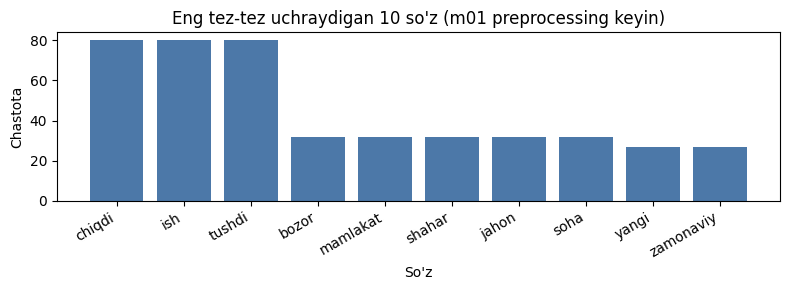

In [62]:
# Vizual tekshiruv: so'z chastotasi (top 10)
try:
    import matplotlib.pyplot as plt
    top = freq.most_common(10)
    words, counts = zip(*top)
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.bar(words, counts, color='#4C78A8')
    ax.set_title("Eng tez-tez uchraydigan 10 so'z (m01 preprocessing keyin)")
    ax.set_xlabel("So'z")
    ax.set_ylabel("Chastota")
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
except Exception as ex:
    print(f"(grafik o'tkazib yuborildi: {type(ex).__name__})")

> **Tekshiring:**
> 1. Eng tez uchraydigan soʼzʼlar kontent soʼzʼlarmi yoki yordamchilar?
> 2. `P_word('telefon')` nechiga teng? Bu Noisy Channel da qanday rol oʼynaydi?
> 3. `m01` preprocessing lugʼat hajmini qanday oʼzgartirdi (tokenizatsiya + stemming)?

In [63]:
# Sanity check: CORPUS, freq, total keyingi bo'limlar uchun tayyor.
# Kaggle darsida alohida checkpoint fayl yozmaymiz — notebook ketma-ket ishlaydi.
assert isinstance(CORPUS, list) and len(CORPUS) > 0, "CORPUS bo'sh. Korpus yuklash katagini tekshiring."
assert len(freq) > 0 and total > 0, "freq/total tayyor emas. 3B katagini tekshiring."
print(f"Tayyor: {len(CORPUS)} hujjat, {len(freq)} so'zli lug'at, {total} token.")


Tayyor: 160 hujjat, 22 so'zli lug'at, 720 token.


## 4. Asosiy mavzu — soʼnuvchi tayanch

Uch bosqichda oʼrganamiz:
- **Namuna** (men koʼrsataman) — toʼliq kod + tushuntirish, assert bilan tasdiqlash
- **Birgalikda** — blanklar `# === SIZNING KODINGIZ ===`, assert keyingi katakda
- **Mustaqil** — scaffold yoʼq, oʼz soʼzʼlaringiz va soʼrovingiz

### 4A. Namuna: Levenshtein tahrir masofasi — L4 [I3]-slayd

**Bu katakning natijasi toʼridan-toʼri L4 maʼruzasidagi qoʼlʼda misol bilan bogʼliq.**

DP jadval: 


$D[i][j] = \min(D[i{-}1][j]+1,\; D[i][j{-}1]+1,\; D[i{-}1][j{-}1]+\mathbf{1}[s_1[i]\ne s_2[j]])$.

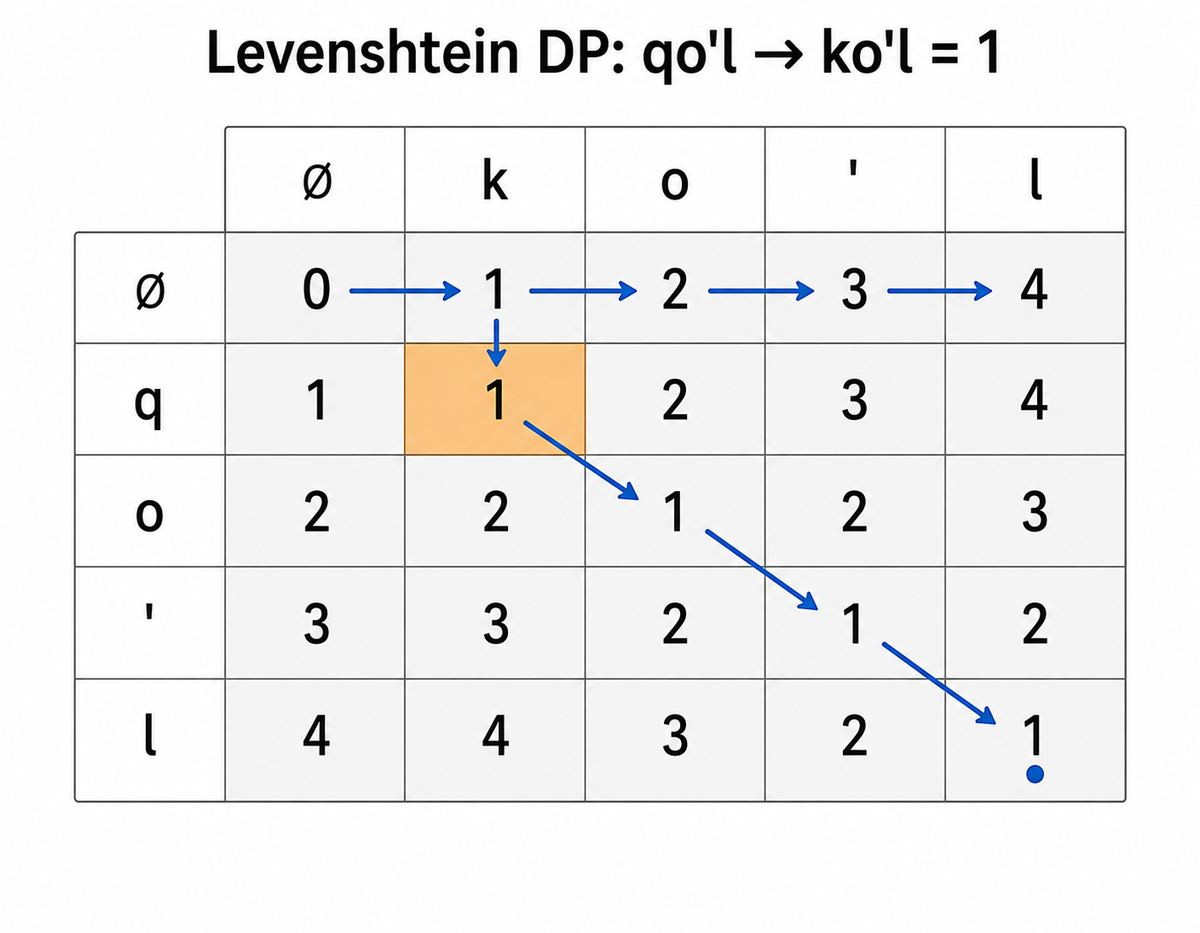

In [64]:
# Namuna (men ko'rsataman): edit_distance DP
def edit_distance(s1, s2):
    m, n = len(s1), len(s2)
    D = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1): D[i][0] = i      # o'chirish
    for j in range(n+1): D[0][j] = j      # qo'shish
    for i in range(1, m+1):
        for j in range(1, n+1):
            if s1[i-1] == s2[j-1]:
                D[i][j] = D[i-1][j-1]
            else:
                D[i][j] = 1 + min(D[i-1][j],      # o'chirish
                                  D[i][j-1],       # qo'shish
                                  D[i-1][j-1])     # almashtirish
    return D[m][n]

d_qol = edit_distance("qo'l", "ko'l")
d_das = edit_distance('dastur', 'dastir')
print(f"edit_distance('qo'l', 'ko'l')     = {d_qol}")
print(f"edit_distance('dastur', 'dastir') = {d_das}")

# ─── Assert: Ma'ruza L4 [I3]-slayd bilan solishtiring ──────────────────
assert edit_distance("qo'l", "ko'l") == 1,    "qo'l→ko'l: 1 ta almashtirish (q→k)."
assert edit_distance('dastur', 'dastir') == 1, 'dastur→dastir: 1 ta almashtirish (u→i).'
# Ma'ruza L4 [I3]-slayd bilan solishtiring
print("\n✓ Ma'ruza L4 [I3]-slayd tasdiqlandi: edit_distance = 1")

edit_distance('qo'l', 'ko'l')     = 1
edit_distance('dastur', 'dastir') = 1

✓ Ma'ruza L4 [I3]-slayd tasdiqlandi: edit_distance = 1


### 4B. Birgalikda: Noisy Channel imlo tuzatish

$\hat{w} = \arg\max_w P(w)\cdot P(x{\mid}w)$, bunda:
- $P(w) = \text{freq}[w] / \text{total}$ — til modeli (korpusdan)
- $P(x{\mid}w) = \alpha^{\text{edit}(x,w)}$ — kanal modeli ($\alpha=0.1$, yaqin soʼz = ehtimoliyroq)
- Nomzodlar: tahrir masofasi $\le 2$ boʼlgan lugʼat soʼzʼlar

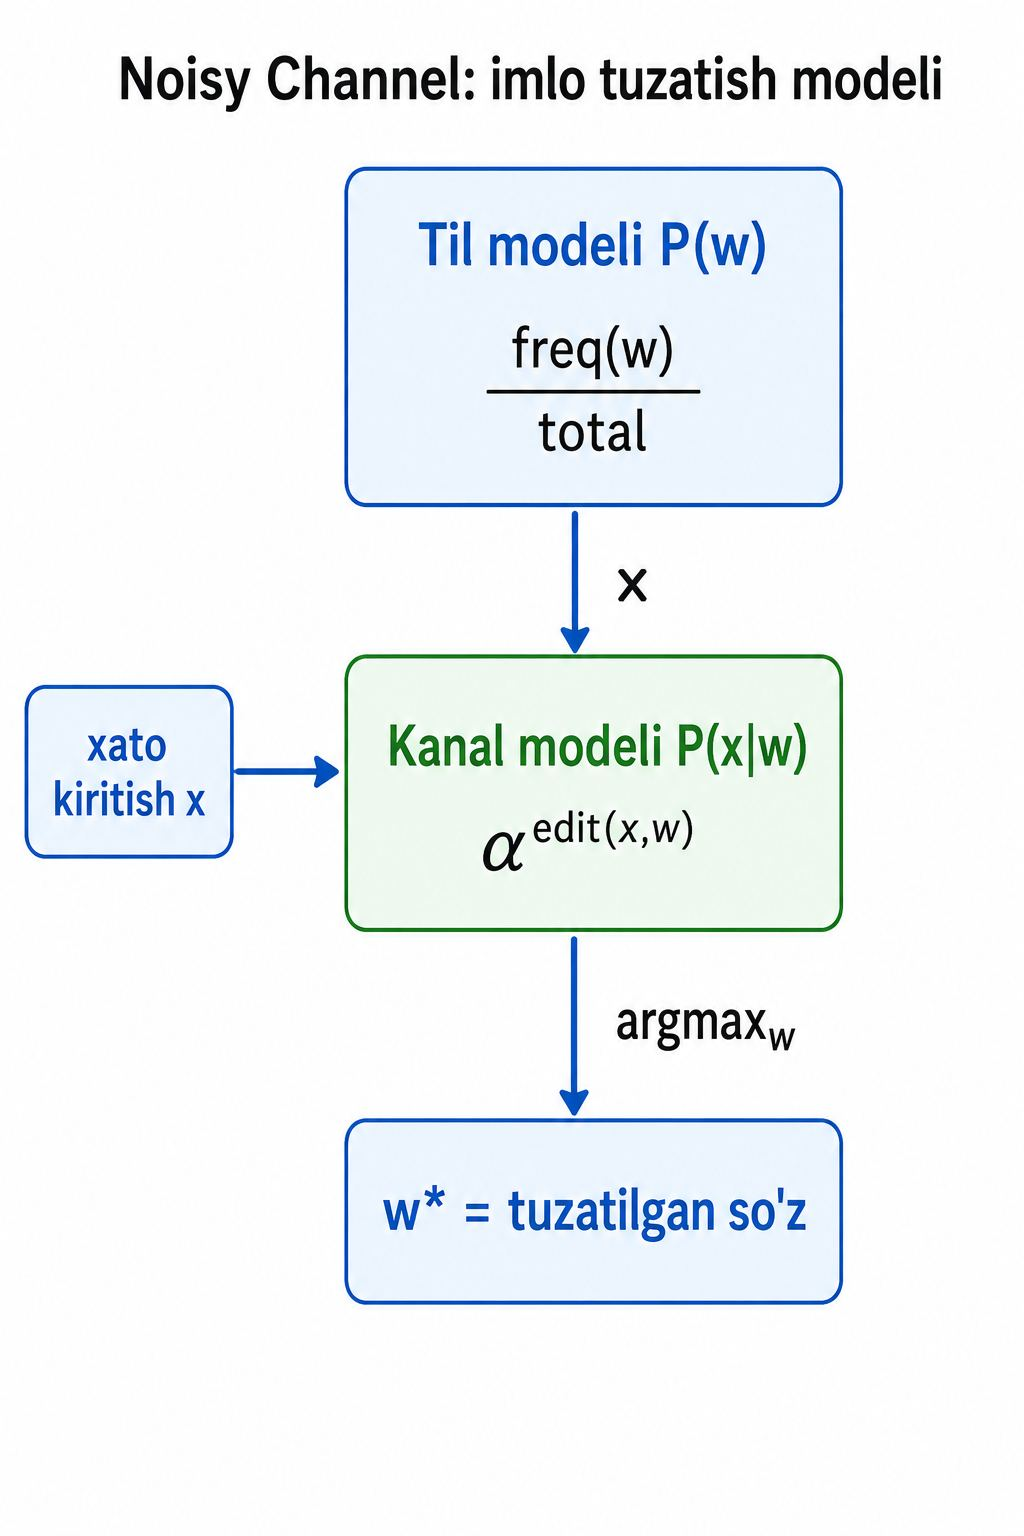

In [65]:
# Birgalikda: correct() — Noisy Channel imlo tuzatish
ALPHA = 0.1   # kanal modeli: P(x|w) = ALPHA ** edit_distance

def correct(x):
    x = x.lower()
    if x in freq:          # lug'atda bor -> tuzatish shart emas
        return x
    best, best_score = x, -1.0
    for w in freq:
        d = edit_distance(x, w)
        if d > 2:
            continue
        # === SIZNING KODINGIZ (1 qator) ===
        # noisy channel ball: P(w) * ALPHA**d   (P(w) = freq[w] / total)
        score = score = (freq[w] / total) * (ALPHA ** d)
        if score is not None and score > best_score:
            best, best_score = w, score
    return best

print(f"correct('telfon')  -> {correct('telfon')}")
print(f"correct('internt') -> {correct('internt')}")

correct('telfon')  -> telefon
correct('internt') -> internet


In [66]:
assert correct('telfon') == 'telefon', (
    f"correct('telfon') = {correct('telfon')!r}, kutilgan 'telefon'. "
    'Noisy channel ballini tekshiring: (freq[w]/total) * ALPHA**d.'
)
assert correct('internt') == 'internet', "correct('internt') 'internet' bo'lishi kerak."
assert correct('telefon') == 'telefon',  "Lug'atdagi so'z o'zgarmasligi kerak."
print("✓ Noisy Channel to'g'ri: telfon→telefon, internt→internet")

✓ Noisy Channel to'g'ri: telfon→telefon, internt→internet


### 4C. Birgalikda: MinHash LSH indeks va lsh_candidates()

LSH faqat bir savatga tushgan **nomzodlarni** tekshiradi — k-NN esa hammasini.
Avval 64-xeshli imzo va band/savat strukturasini quramiz.

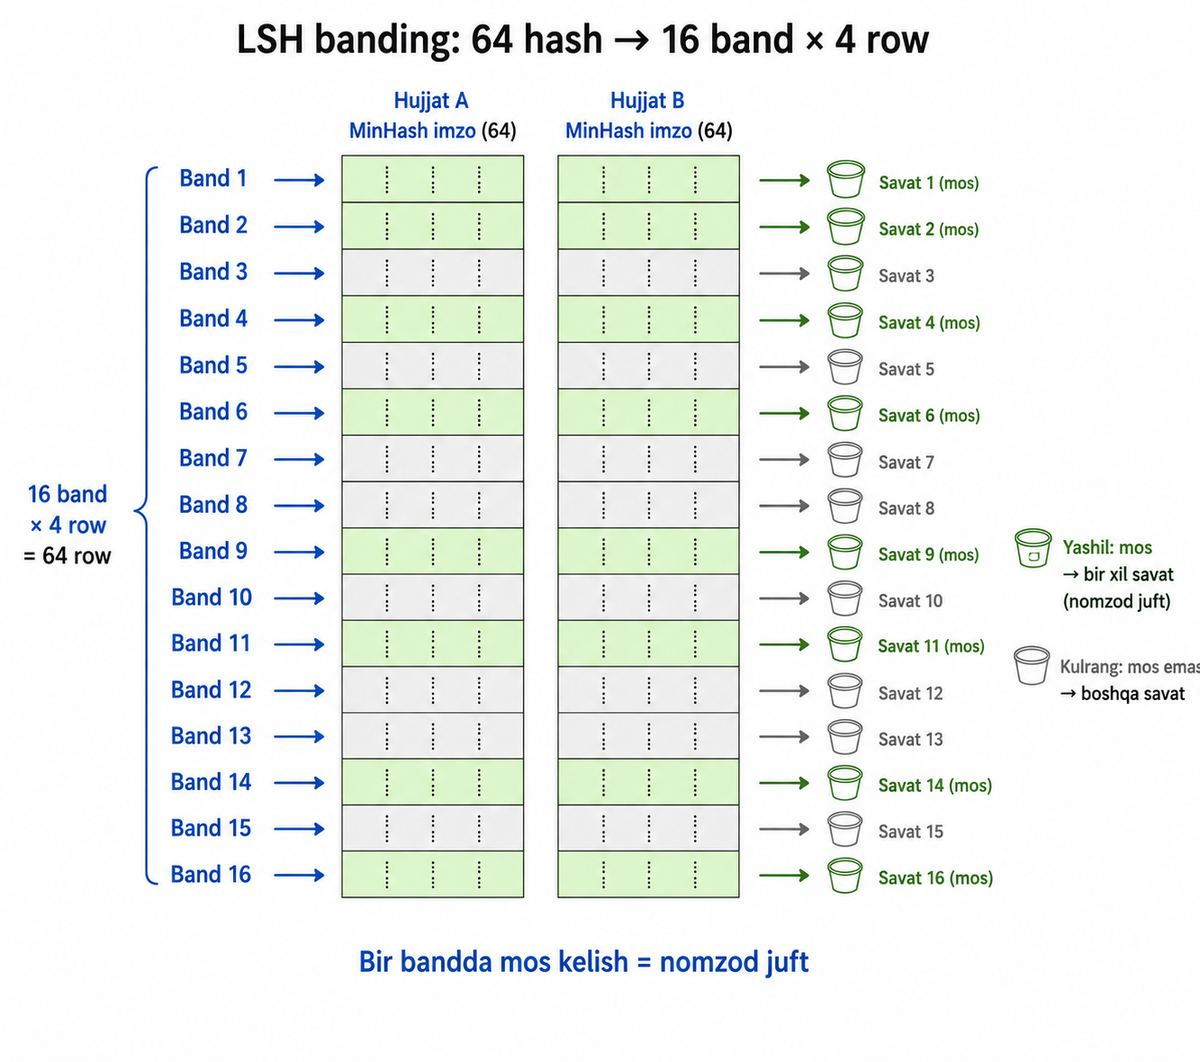

In [67]:
# Birgalikda: MinHash LSH indeks
NUM_PERM, BANDS = 64, 16
ROWS = NUM_PERM // BANDS
rng_lsh = np.random.RandomState(42)
A = rng_lsh.randint(1, 2**31-1, NUM_PERM)
B = rng_lsh.randint(0, 2**31-1, NUM_PERM)
PRIME = 2**31-1

def shingles(text):
    return set(pre.preprocess(text))

def signature(sh):
    if not sh:
        return tuple([PRIME]*NUM_PERM)
    hs   = np.array([stable_hash(t) for t in sh])
    Msig = (A[:,None]*hs[None,:] + B[:,None]) % PRIME
    return tuple(int(x) for x in Msig.min(axis=1))

# Barcha hujjatlar uchun shingle to'plami va savat (bucket) jadvalini quramiz
doc_sh  = [shingles(d) for d in CORPUS]
buckets = {}
for i, sh in enumerate(doc_sh):
    sig = signature(sh)
    for band in range(BANDS):
        key = (band, sig[band*ROWS:(band+1)*ROWS])
        buckets.setdefault(key, set()).add(i)

def lsh_candidates(query):
    sig  = signature(shingles(query))
    cand = set()
    for band in range(BANDS):
        key = (band, sig[band*ROWS:(band+1)*ROWS])
        # === SIZNING KODINGIZ (1 qator) ===
        # shu band kalitidagi hujjatlarni cand ga qo'shing: buckets.get(key, set())
        cand.update(buckets.get(key, set()))
    return cand

query = CORPUS[0]
cand  = lsh_candidates(query)
print(f"So'rov        : '{query}'")
print(f"LSH nomzodlar : {len(cand)} ta  (jami hujjat: {len(CORPUS)})")

So'rov        : 'yangi telefon bozorda chiqdi'
LSH nomzodlar : 4 ta  (jami hujjat: 160)


In [68]:
def jaccard(p, q):
    return len(p & q) / len(p | q) if (p and q) else 0.0

def retrieve_lsh(query, k=5):
    qsh    = shingles(query)
    scored = sorted(((jaccard(qsh, doc_sh[i]), CORPUS[i]) for i in lsh_candidates(query)),
                    key=lambda x: -x[0])
    return [d for _, d in scored[:k]]

def retrieve_bruteforce(query, k=5):
    qsh    = shingles(query)
    scored = sorted(((jaccard(qsh, doc_sh[i]), CORPUS[i]) for i in range(len(CORPUS))),
                    key=lambda x: -x[0])
    return [d for _, d in scored[:k]]

assert cand is not None and len(cand) > 0, (
    "LSH nomzodlari bo'sh. lsh_candidates() ni tekshiring — 'pass' ni almashtirdingizmi?"
)
assert len(cand) < len(CORPUS), (
    f"LSH nomzodlari ({len(cand)}) jami hujjatdan ({len(CORPUS)}) kam bo'lishi kerak."
)
assert retrieve_lsh(query, 1)[0] == retrieve_bruteforce(query, 1)[0], (
    "LSH eng yaqin hujjati k-NN bilan mos kelmadi. lsh_candidates() ni tekshiring."
)
print(f"✓ LSH {len(cand)} nomzodni tekshiradi ({len(CORPUS)} o'rniga) — eng yaqinni topadi.")

✓ LSH 4 nomzodni tekshiradi (160 o'rniga) — eng yaqinni topadi.


### 4D. k-NN vs LSH

Kichik korpusda farq kam; katta korpusda LSH ancha tez.

In [69]:
# Birgalikda: tezlik taqqoslash
import time
queries = CORPUS[:20]

t0 = time.perf_counter()
for q in queries: retrieve_bruteforce(q, 5)
t_bf = time.perf_counter() - t0

t0 = time.perf_counter()
for q in queries: retrieve_lsh(q, 5)
t_lsh = time.perf_counter() - t0

# === SIZNING KODINGIZ (1 qator) ===
# o'rtacha LSH nomzodlar sonini hisoblang -> avg_cand
avg_cand = sum(len(lsh_candidates(q)) for q in queries) / len(queries)

print(f"k-NN (brute-force): {t_bf*1000:.1f} ms  ({len(CORPUS)} solishtirish/so'rov)")
print(f"LSH               : {t_lsh*1000:.1f} ms  ({avg_cand} nomzod/so'rov o'rtacha)")

k-NN (brute-force): 4.3 ms  (160 solishtirish/so'rov)
LSH               : 3.5 ms  (11.85 nomzod/so'rov o'rtacha)


In [70]:
assert avg_cand is not None, "avg_cand None. O'rtacha nomzodlar sonini hisoblang."
assert avg_cand < len(CORPUS), (
    f"O'rtacha nomzod ({avg_cand:.1f}) jami hujjatdan ({len(CORPUS)}) kam bo'lishi kerak."
)
print(f"✓ LSH har so'rovda o'rtacha {avg_cand:.1f} hujjatni tekshiradi ({len(CORPUS)} o'rniga).")

✓ LSH har so'rovda o'rtacha 11.8 hujjatni tekshiradi (160 o'rniga).


### 4E. Mustaqil: oʼz xato soʼzʼing va soʼroving

Scaffold yoʼq — `correct()` va `retrieve_lsh()` dan foydalaning.

In [71]:
# Mustaqil (siz qilasiz):
# 1. O'z imlo xatongizni tuzating.
# 2. O'z so'rovingiz uchun eng o'xshash 3 hujjatni toping.
my_typo  = 'kompyutr'
my_query = 'yangi telefon'


# === SIZNING KODINGIZ ===
my_fixed = correct(my_typo)
my_results = retrieve_lsh(my_query, 3)

In [72]:
assert my_fixed is not None and isinstance(my_fixed, str), "my_fixed None yoki str emas."
assert my_results is not None and isinstance(my_results, list), "my_results ro'yxat bo'lishi kerak."
assert len(my_results) <= 3, "retrieve_lsh(query, 3) — 3 tadan ko'p qaytarmasligi kerak."
print(f"✓ Mustaqil: '{my_typo}' -> '{my_fixed}'")
print(f"  So'rov '{my_query}' uchun {len(my_results)} natija topildi.")

✓ Mustaqil: 'kompyutr' -> 'kompyuter'
  So'rov 'yangi telefon' uchun 3 natija topildi.


## 5. Loyihaga ulash — `SpellLSHRetriever` yozamiz

4-boʼlim funksiyalarini (`edit_distance`, `correct`, `lsh_candidates`, `retrieve_lsh`)
rasmiy kapstone klassiga oʼrtkazamiz. Bu **Option C** koʼrinishi: klass notebook ichida
toʼliq ishlaydi. Kaggle darsida fayl yozish shart emas; capstone moduli repoda tayyor.

Shartnoma (`capstone/contracts.py`):
- `correct(word: str) -> str`
- `index_docs(texts: list[str])`
- `retrieve_lsh(query: str, k: int) -> list[str]`

In [73]:
# m04 SpellLSHRetriever — inline ta'rif (Option C)
import pickle

class SpellLSHRetriever:
    '''Imlo tuzatish (Noisy Channel + Levenshtein) va MinHash LSH qidiruv.

    Shartnoma: fit_dictionary(texts) | correct(word) -> str
               index_docs(texts) | retrieve_lsh(query, k) -> list[str]
    Consumed by: m15 (agent tool: spell_correct), Day 16 (pipeline).
    '''

    def __init__(self, num_perm=64, bands=16, alpha=0.1):
        try:
            from m01_text_preprocessor import TextPreprocessor
        except ImportError:
            from .m01_text_preprocessor import TextPreprocessor
        self._pre   = TextPreprocessor()
        self._np    = num_perm
        self._bands = bands
        self._rows  = num_perm // bands
        self._alpha = alpha
        import numpy as np
        rng       = np.random.RandomState(42)
        self._a   = rng.randint(1, 2**31-1, num_perm).astype(np.int64)
        self._b   = rng.randint(0, 2**31-1, num_perm).astype(np.int64)
        self._P   = np.int64(2**31-1)
        self._freq    = {}
        self._total   = 0
        self._docs    = []
        self._shing   = []
        self._buckets = {}

    def _tok(self, text):
        return set(self._pre.preprocess(text)) if text.strip() else set()

    @staticmethod
    def _hash(s):
        import zlib
        return zlib.crc32(s.encode("utf-8")) & 0x7FFFFFFF

    def _sig(self, sh):
        import numpy as np
        if not sh: return tuple([int(self._P)] * self._np)
        hs = np.array([self._hash(t) for t in sh], dtype=np.int64)
        M  = (self._a[:,None]*hs[None,:] + self._b[:,None]) % self._P
        return tuple(int(x) for x in M.min(axis=1))

    # ── imlo tuzatish ─────────────────────────────────────────────────────
    def edit_distance(self, s1, s2):
        '''Levenshtein tahrir masofasi — 2D DP jadval.'''
        m, n = len(s1), len(s2)
        D = [[0]*(n+1) for _ in range(m+1)]
        for i in range(m+1): D[i][0] = i
        for j in range(n+1): D[0][j] = j
        for i in range(1, m+1):
            for j in range(1, n+1):
                D[i][j] = (D[i-1][j-1] if s1[i-1]==s2[j-1]
                           else 1+min(D[i-1][j], D[i][j-1], D[i-1][j-1]))
        return D[m][n]

    def fit_dictionary(self, texts):
        '''Til modeli P(w) ni korpusdan o'rganadi.'''
        from collections import Counter
        freq = Counter(w for t in texts for w in self._pre.preprocess(t))
        self._freq  = dict(freq)
        self._total = sum(freq.values())

    def correct(self, word):
        '''Noisy channel: argmax_w P(w) x P(x|w).'''
        w = word.lower()
        if not self._total or w in self._freq: return w
        best, best_sc = w, -1.0
        for cand, c in self._freq.items():
            d = self.edit_distance(w, cand)
            if d > 2: continue
            sc = (c / self._total) * (self._alpha ** d)
            if sc > best_sc: best, best_sc = cand, sc
        return best

    # ── LSH indeks ───────────────────────────────────────────────────────────
    def index_docs(self, texts):
        '''Hujjatlarni MinHash LSH indeksiga qo'shadi.'''
        for text in texts:
            i  = len(self._docs)
            sh = self._tok(text)
            self._docs.append(text)
            self._shing.append(sh)
            sig = self._sig(sh)
            for b in range(self._bands):
                key = (b, sig[b*self._rows:(b+1)*self._rows])
                self._buckets.setdefault(key, set()).add(i)

    def lsh_candidates(self, query):
        sig  = self._sig(self._tok(query))
        cand = set()
        for b in range(self._bands):
            key  = (b, sig[b*self._rows:(b+1)*self._rows])
            cand |= self._buckets.get(key, set())
        return cand

    def retrieve_lsh(self, query, k=5):
        '''LSH orqali eng o'xshash k ta hujjatni qaytaradi.'''
        qsh = self._tok(query)
        def jac(a, b): return len(a&b)/len(a|b) if (a and b) else 0.0
        scored = [(jac(qsh, self._shing[i]), self._docs[i])
                  for i in self.lsh_candidates(query)]
        scored.sort(key=lambda x: -x[0])
        return [d for _, d in scored[:k]]

    # ── saqlash / yuklash ───────────────────────────────────────────────────
    def save(self, path):
        state = {
            '_np': self._np, '_bands': self._bands, '_rows': self._rows,
            '_alpha': self._alpha,
            '_a': self._a.tolist(), '_b': self._b.tolist(),
            '_freq': self._freq, '_total': self._total,
            '_docs': self._docs,
            '_shing': [list(s) for s in self._shing],
            '_buckets': {k: list(v) for k, v in self._buckets.items()},
        }
        with open(path, 'wb') as f: pickle.dump(state, f)

    def load(self, path):
        import numpy as np
        with open(path, 'rb') as f: s = pickle.load(f)
        self.__init__(s['_np'], s['_bands'], s['_alpha'])
        self._a       = np.array(s['_a'], dtype=np.int64)
        self._b       = np.array(s['_b'], dtype=np.int64)
        self._freq    = s['_freq']
        self._total   = s['_total']
        self._docs    = s['_docs']
        self._shing   = [set(x) for x in s['_shing']]
        self._buckets = {k: set(v) for k, v in s['_buckets'].items()}

print('✓ SpellLSHRetriever sinfi aniqlandi.')

✓ SpellLSHRetriever sinfi aniqlandi.


In [74]:
# Shartnoma tekshiruvi
import tempfile, os

sp = SpellLSHRetriever()

# edit_distance -> int   (L4 [I3] qulflangan qiymat)
assert sp.edit_distance("qo'l", "ko'l") == 1       # Ma'ruza L4 [I3]-slayd
assert sp.edit_distance('dastur', 'dastir') == 1

# correct -> str
sp.fit_dictionary(CORPUS)
assert sp.correct('telfon')  == 'telefon'
assert sp.correct('internt') == 'internet'
assert sp.correct('telefon') == 'telefon'

# index_docs / retrieve_lsh -> list[str]
sp.index_docs(CORPUS)
res = sp.retrieve_lsh(CORPUS[0], k=3)
assert isinstance(res, list) and len(res) >= 1 and isinstance(res[0], str)
assert res[0] == CORPUS[0], "So'rov korpus hujjati bo'lsa, o'zi eng yaqin bo'lishi kerak."

# save / load roundtrip
_tmp = os.path.join(tempfile.gettempdir(), 'm04_test.pkl')
sp.save(_tmp)
sp2 = SpellLSHRetriever(); sp2.load(_tmp)
assert sp2.correct('telfon') == 'telefon'
assert sp2.retrieve_lsh(CORPUS[0], 1)[0] == CORPUS[0]

print('✓ SpellLSHRetriever barcha shartnoma tekshiruvlaridan o\'tdi!')
_ed_demo = sp.edit_distance("qo'l", "ko'l")
_cr_demo = sp.correct('telfon')
print(f"  edit_distance(qo'l, ko'l) = {_ed_demo}")
print(f"  correct('telfon') = {_cr_demo}")
print(f"  retrieve_lsh top-1: {res[0]!r}")

✓ SpellLSHRetriever barcha shartnoma tekshiruvlaridan o'tdi!
  edit_distance(qo'l, ko'l) = 1
  correct('telfon') = telefon
  retrieve_lsh top-1: 'yangi telefon bozorda chiqdi'


In [75]:
# Kaggle darsida fayl yozish majburiy emas.
# Capstone moduli repoda allaqachon capstone/modules/m04_spell_lsh_retriever.py sifatida mavjud.
if SAVE_CAPSTONE_MODULE:
    import inspect
    _header = (
        '# capstone/modules/m04_spell_lsh_retriever.py\n'
        "# SpellLSHRetriever — P4 notebookidan (Option C, to'liq versiyasi).\n"
        '# Consumed by: m15 (agent tool: spell_correct), Day 16 (pipeline).\n'
        'from __future__ import annotations\n'
        'import pickle, zlib\n'
        'from collections import Counter\n'
        'import numpy as np\n\n'
    )
    _src  = _header + inspect.getsource(SpellLSHRetriever)
    _path = MODULES_DIR / 'm04_spell_lsh_retriever.py'
    _path.parent.mkdir(parents=True, exist_ok=True)
    _path.write_text(_src, encoding='utf-8')
    print(f'✓ m04 saqlandi: {_path}')
else:
    print('Kaggle rejimi: fayl yozilmadi. SpellLSHRetriever sinfi notebookda tayyor.')


Kaggle rejimi: fayl yozilmadi. SpellLSHRetriever sinfi notebookda tayyor.


### 5C. Kaggle eslatma

Kaggle darsida commit yoki terminal buyruqlari kerak emas. Notebookdagi `SpellLSHRetriever` sinfi ishlaydi; repodagi capstone fayl esa alohida saqlangan.


In [78]:
print("Kaggle rejimi: terminal yoki commit bosqichi yo'q. Notebook natijalari tayyor.")


Kaggle rejimi: terminal yoki commit bosqichi yo'q. Notebook natijalari tayyor.


## 6. Tadqiqot savoli + yakun

**Savol:** Oʼzbek imlosida apostrof variantlari (`oʼ` / `oʻ` / `o`) va
agglutinatsiya tuzatishni qiyinlashtiradi. Nega?
LSH “taxminiy” — qachon oʼxshash hujjatni oʼtkazib yuborishi mumkin?

In [79]:
# Mini tadqiqot: apostrof va agglutinatsiya
print('Apostrof variantlari orasidagi tahrir masofasi:')
for x, y in [("qo'l", 'qol'), ("to'g'ri", 'togri'), ("ma'no", 'mano')]:
    print(f'  edit_distance({x!r}, {y!r}) = {edit_distance(x, y)}')

print('\nAgglutinatsiya — bitta o\'zak, ko\'p nomzod:')
forms = ['telefon', 'telefonni', 'telefonga', 'telefonlar']
for f in forms:
    print(f"  edit_distance('telefon', {f!r}) = {edit_distance('telefon', f)}")
print('  -> normallashtirish (m01 stemming) nomzodlar sonini kamaytiradi.')

print('\nLSH taxminiyligi: o\'xshash hujjat boshqa savatga tushib, topilmay qolishi mumkin.')
print(f'  Hozirgi sozlamalar: {BANDS} band x {ROWS} row = {NUM_PERM} perm')
print('  False-negative ehtimoli: BANDS yoki ROWS ni o\'zgartiring, taqqoslang.')

Apostrof variantlari orasidagi tahrir masofasi:
  edit_distance("qo'l", 'qol') = 1
  edit_distance("to'g'ri", 'togri') = 2
  edit_distance("ma'no", 'mano') = 1

Agglutinatsiya — bitta o'zak, ko'p nomzod:
  edit_distance('telefon', 'telefon') = 0
  edit_distance('telefon', 'telefonni') = 2
  edit_distance('telefon', 'telefonga') = 2
  edit_distance('telefon', 'telefonlar') = 3
  -> normallashtirish (m01 stemming) nomzodlar sonini kamaytiradi.

LSH taxminiyligi: o'xshash hujjat boshqa savatga tushib, topilmay qolishi mumkin.
  Hozirgi sozlamalar: 16 band x 4 row = 64 perm
  False-negative ehtimoli: BANDS yoki ROWS ni o'zgartiring, taqqoslang.


## Yakun

**Bugun nimalar qildik:**
- ✓ Levenshtein tahrir masofasini DP bilan yozdik — L4 [I3]: edit('qoʼl','koʼl')=1
- ✓ Noisy Channel imlo tuzatish: telfon→telefon, internt→internet
- ✓ MinHash LSH indeks qurdik va k-NN bilan tezlikni taqqosladik
- ✓ `SpellLSHRetriever` (Option C) barcha shartnoma tekshiruvlaridan oʼtti

**Keyingi amaliyot (P5 — N-grammalar va avtotoʼldirishlar):**
Bigramma/trigramma chastotalari → avtomatik toʼldirish → HMM POS tagger → m05.
Birinchi assert: Viterbi ketma-ketligi = `['NN', 'VB']`, $\delta(VB,t=2)=0.3402$ (L5 [I]).

---

> **Chiqish chiptasi:** Bugun eng tushunarsiz qolgan narsa nima?
> *(Quyidagi katakka yozing — keyingi darsda muhokama qilamiz.)*